In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
df = pd.read_csv("통합.csv", encoding="utf-8")
df_walse = df[df['거래_정보.거래방식'].str.contains('월세', na=False)]

In [3]:
df_walse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6351 entries, 3 to 9911
Data columns (total 50 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   매물번호            6351 non-null   int64  
 1   매물_URL          6351 non-null   object 
 2   매물_이미지          6317 non-null   object 
 3   평면도_URL         305 non-null    object 
 4   추가_옵션           5772 non-null   object 
 5   주변_학교           0 non-null      float64
 6   상세_설명           6309 non-null   object 
 7   주소_정보.전체주소      6351 non-null   object 
 8   거래_정보.거래방식      6351 non-null   object 
 9   거래_정보.관리비       6351 non-null   object 
 10  거래_정보.융자금       6229 non-null   object 
 11  거래_정보.입주가능일     6351 non-null   object 
 12  매물_정보.전입신고 여부   6351 non-null   object 
 13  매물_정보.건축물용도     6229 non-null   object 
 14  매물_정보.건물형태      5303 non-null   object 
 15  매물_정보.전용/공급면적   6347 non-null   object 
 16  매물_정보.해당층/전체층   6347 non-null   object 
 17  매물_정보.방/욕실개수    6351 non-null   object

In [4]:

df_walse = df_walse.drop(columns=[
        "매물번호", "평면도_URL", "매물_이미지", "매물_URL",
        "주변_학교", "거래_정보.융자금", "거래_정보.입주가능일",
        "매물_정보.전입신고 여부", "매물_정보.현관유형",
        "매물_정보.총세대수", "매물_정보.총주차대수",
        "매물_정보.난방방식", "매물_정보.냉방시설", "매물_정보.보안시설",
        "중개사_정보.중개사명", "중개사_정보.대표자", "중개사_정보.전화번호",
        "중개사_정보.주소", "중개사_정보.등록번호", "중개사_정보.거래완료",
        "중개사_정보.등록매물", "매물_정보.건물명", "매물_정보.동",
        "매물_정보.계약기간", "매물_정보.연/대지면적", "매물_정보.용적률/건쳬율",
        "매물_정보.준공인가일", "중개사_정보.담당자", "매물_정보.사용검사일",
        " 매물_정보.건축/전용면적","매물_정보.용적률/건폐율","매물_정보.지상/지하총층",
        "매물_정보.오피스텔명","매물_정보.아파트명","매물_정보.사용승인일"

    ], errors="ignore")


In [5]:
df_walse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6351 entries, 3 to 9911
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   추가_옵션           5772 non-null   object
 1   상세_설명           6309 non-null   object
 2   주소_정보.전체주소      6351 non-null   object
 3   거래_정보.거래방식      6351 non-null   object
 4   거래_정보.관리비       6351 non-null   object
 5   매물_정보.건축물용도     6229 non-null   object
 6   매물_정보.건물형태      5303 non-null   object
 7   매물_정보.전용/공급면적   6347 non-null   object
 8   매물_정보.해당층/전체층   6347 non-null   object
 9   매물_정보.방/욕실개수    6351 non-null   object
 10  매물_정보.방거실형태     6179 non-null   object
 11  매물_정보.주실기준/방향   6229 non-null   object
 12  매물_정보.주차        6351 non-null   object
 13  매물_정보.위반건축물 여부  5289 non-null   object
 14  매물_정보.생활시설      6187 non-null   object
 15  매물_정보.기타시설      6187 non-null   object
 16  매물_정보.건축/전용면적   4 non-null      object
dtypes: object(17)
memory usage: 893.1+ KB


In [6]:
df_walse["거래_정보.거래방식"]

3         월세   2,500만원/104만원
6          월세   5,000만원/95만원
8               월세   3억/20만원
10        월세   5,000만원/115만원
11         월세   2,000만원/55만원
                ...         
9905       월세   1,000만원/95만원
9906    월세   1억 6,000만원/20만원
9909            월세   2억/55만원
9910       월세   1,000만원/85만원
9911       월세   1,000만원/85만원
Name: 거래_정보.거래방식, Length: 6351, dtype: object

In [7]:
df_walse["매물_정보.방/욕실개수"].value_counts()


매물_정보.방/욕실개수
1개/1개      4919
2개/1개      1280
3개/1개        84
3개/2개        28
2개/2개        13
1개/0개        10
0개/1개         4
1개/2개         3
1개/11개        1
1개/14개        1
4개/2개         1
1개/3개         1
6개/6개         1
8개/3개         1
30개/30개       1
20개/20개       1
1개/127개       1
1개/4개         1
Name: count, dtype: int64

In [8]:
import re

In [9]:
# 숫자 + 만원/억 단위 문자열을 숫자로 변환하는 함수
def parse_korean_money(text):
    if pd.isna(text):
        return 0
    
    text = text.replace(",", "").strip()

    # 앞뒤의 불필요한 단어 제거 (예: "월세 2500만원")
    text = re.sub(r"[^\d억만]", "", text)

    # 억 단위 포함
    if "억" in text:
        parts = text.split("억")
        eok = int(parts[0]) if parts[0] else 0

        man = 0
        if len(parts) > 1 and "만" in parts[1]:
            man = int(parts[1].replace("만", ""))

        return eok * 10000 + man  # 만원 단위로 반환

    # 억 없음 → 그냥 만원 단위 숫자
    numbers = re.findall(r"\d+", text)
    if numbers:
        return int(numbers[0])
    
    return 0

# "보증금/월세" 분리
def split_deposit_rent(x):
    # 혹시 "월세 2500/50" 같은 경우도 대비
    x = x.replace(" ", "")

    deposit, rent = x.split("/")
    deposit = parse_korean_money(deposit)
    rent = parse_korean_money(rent)
    return pd.Series([deposit, rent])


# 데이터프레임에 적용
df_walse[["보증금", "월세"]] = df_walse["거래_정보.거래방식"].apply(split_deposit_rent)

# 월세 전환 보증금 계산
df_walse["월세_전환보증금"] = df_walse["월세"] * 12 / 0.06

# 최종 환산보증금 계산
df_walse["환산보증금"] = df_walse["보증금"] + df_walse["월세_전환보증금"]


In [10]:
df_walse["환산보증금"]

3       23300.0
6       24000.0
8       34000.0
10      28000.0
11      13000.0
         ...   
9905    20000.0
9906    20000.0
9909    31000.0
9910    18000.0
9911    18000.0
Name: 환산보증금, Length: 6351, dtype: float64

In [11]:
def extract_area(value):
    """
    전용/공급면적에서 전용면적(㎡)만 추출.
    예: '30m2/38.68m2' -> 30.0
    """
    if pd.isna(value):
        return None
    try:
        text = str(value).replace(" ", "").strip()
        area_str = text.split('/')[0].replace("m2", "")
        return float(area_str)
    except:
        return None
def convert_to_pyeong_from_raw(value):
    """
    '30m2/38.68m2' 같은 문자열을 입력받아 바로 평으로 변환.
    """
    area_m2 = extract_area(value)
    if area_m2 is None:
        return None
    return round(area_m2 / 3.3, 2)

col_area = "매물_정보.전용/공급면적"


In [12]:
df_walse["전용면적_m2"] = df_walse[col_area].apply(extract_area)
df_walse["전용면적_평"] = df_walse[col_area].apply(convert_to_pyeong_from_raw)


In [13]:
df_walse["전용면적_m2"]
# df_walse["전용면적_평"]

3       36.04
6       29.79
8       29.76
10      27.39
11      26.45
        ...  
9905    14.09
9906    17.15
9909    30.17
9910    14.35
9911    14.35
Name: 전용면적_m2, Length: 6351, dtype: float64

In [14]:
df_walse["평당가"] = df_walse["환산보증금"] / df_walse["전용면적_평"].replace(0, np.nan)


In [15]:
df_walse["평당가"]

3       2133.699634
6       2657.807309
8       3769.401330
10      3373.493976
11      1620.947631
           ...     
9905    4683.840749
9906    3846.153846
9909    3391.684902
9910    4137.931034
9911    4137.931034
Name: 평당가, Length: 6351, dtype: float64

In [16]:
df_walse["추가_옵션"]

3                         NaN
6           엘리베이터|전세자금대출|주차가능
8         신축|풀옵션|엘리베이터|전세자금대출
10                 엘리베이터|주차가능
11                        NaN
                ...          
9905       풀옵션|큰길가|엘리베이터|주차가능
9906     풀옵션|큰길가|엘리베이터|전세자금대출
9909                     주차가능
9910    신축|풀옵션|큰길가|엘리베이터|주차가능
9911    신축|풀옵션|큰길가|엘리베이터|주차가능
Name: 추가_옵션, Length: 6351, dtype: object

In [17]:
# 관리비
def extract_management_fee(value):
    """
    관리비 문자열에서 '00만원' 형태 중 가장 앞에 나오는 숫자만 추출.
    """
    if pd.isna(value):
        return None

    s = str(value).strip()

    # 맨 앞쪽 "숫자 + 만원" 패턴 첫번째 매칭만 추출
    match = re.search(r'(\d+)\s*만원', s)
    
    if match:
        return int(match.group(1))

    return None
col_area = "거래_정보.관리비"

In [18]:
df_walse["관리비"] = df_walse[col_area].apply(extract_management_fee)

In [19]:
df_walse["관리비"] = df_walse["관리비"].fillna(0)
df_walse["관리비"]

3        7.0
6       20.0
8       10.0
10      10.0
11       5.0
        ... 
9905     9.0
9906     0.0
9909     9.0
9910     8.0
9911     9.0
Name: 관리비, Length: 6351, dtype: float64

In [20]:
# 건축물 용도
def building_usage_score(value):
    """
    매물_정보.건축물용도 → 점수 변환
    1점: 공동주택, 단독주택
    0점: 나머지(근린, 미등기, 업무, 숙박, 교육, '그', NaN 포함)
    """
    if pd.isna(value):
        return 0
    
    s = str(value)

    # 주거용
    if '공동주택' in s or '단독주택' in s:
        return 1

    # 나머지 즉시 0점
    return 0

In [21]:
df_walse["건축물용도"] = df_walse["매물_정보.건축물용도"].apply(building_usage_score)
df_walse["건축물용도"]

3       1
6       1
8       1
10      1
11      0
       ..
9905    1
9906    1
9909    1
9910    1
9911    1
Name: 건축물용도, Length: 6351, dtype: int64

In [22]:
def building_type_score(value):
    """
    매물_정보.건물형태 → 점수 변환
    규칙 순서:
        0점: nan, 미등기, 상가
        1점: '전체', '주택'
        2점: 원룸
        3점: 빌라, 연립
        4점: 다가구
    """
    if pd.isna(value):
        return 0
    
    s = str(value).strip()

    # 0점 규칙 (최우선)
    if '미등기' in s:
        return 0
    if '상가' in s:  # 해충과 쥐 등 문제로 상가주택은 0점 처리
        return 0

    # 1점 규칙
    if '전체' in s:   # 단독 (건물 전체), 다가구 (건물 전체)
        return 1
    if '주택' in s:   # 빌라/주택, 상가주택(단 상가 규칙이 먼저 걸림)
        return 1

    # 2점 규칙
    if '원룸' in s:
        return 2

    # 3점 규칙
    if '빌라' in s or '연립' in s:
        return 3

    # 4점 규칙
    if '다가구' in s:
        return 4

    # 정의되지 않은 기타 값은 기본 0 처리
    return 0

In [23]:
df_walse["건물형태"] = df_walse["매물_정보.건물형태"].apply(building_type_score)
df_walse["건물형태"]

3       3
6       3
8       3
10      3
11      1
       ..
9905    0
9906    0
9909    0
9910    0
9911    0
Name: 건물형태, Length: 6351, dtype: int64

In [24]:
def extract_floor_info(value):
    """
    '해당층/전체층' 문자열에서
    (해당층_숫자, 전체층_숫자, 층_타입, 층_점수)를 반환.

    층_타입: '지하', '저층', '중층', '고층', '옥탑', '알수없음'
    층_점수: 지하 < 저층 < 옥탑 < 중층 < 고층
    """
    if pd.isna(value):
        return (None, None, None, None)

    s = str(value).strip()
    parts = s.split('/')

    floor_raw = parts[0].strip()              # '3층(옥탑)', '중층', 'B1층' 등
    total_raw = parts[1].strip() if len(parts) > 1 else None  # '10층', '17층' 등

    # -----------------------------
    # 1) 지하 여부 체크 ('지', 'B')
    # -----------------------------
    # 반지층, 반지하, 지하, B1층 등
    if any(tok in floor_raw for tok in ['지하', '반지하', '반지층', 'B', 'b']):
        floor_num = -1
        floor_type = '지하'
        total_floors = None
        if total_raw:
            m_tot = re.search(r'\d+', total_raw)
            if m_tot:
                total_floors = int(m_tot.group(0))
        floor_score = -1  # 지하는 항상 마이너스
        return (floor_num, total_floors, floor_type, floor_score)

    # -----------------------------
    # 2) 옥탑 여부
    # -----------------------------
    is_rooftop = ('옥' in floor_raw)  # '옥탑', '옥상', '2층(옥탑)' 등

    # -----------------------------
    # 3) 숫자 층 추출
    # -----------------------------
    floor_num = None
    m_floor = re.search(r'-?\d+', floor_raw)
    if m_floor:
        floor_num = int(m_floor.group(0))

    total_floors = None
    if total_raw:
        m_tot = re.search(r'\d+', total_raw)
        if m_tot:
            total_floors = int(m_tot.group(0))

    # -----------------------------
    # 4) 기본 층 타입 텍스트 기반
    # -----------------------------
    floor_type = '중층'  # 기본값

    if '저층' in floor_raw:
        floor_type = '저층'
    elif '고층' in floor_raw:
        floor_type = '고층'
    elif '중층' in floor_raw:
        floor_type = '중층'

    # -----------------------------
    # 5) 전체층/해당층 숫자 기준 규칙 반영
    #    - 전체층 ≤ 3 → 저층
    #    - 해당층 ≤ 2 → 저층
    #    - 그 외는 비율로 저/중/고층 나누기
    # -----------------------------
    if total_floors is not None and total_floors <= 3:
        floor_type = '저층'
    elif floor_num is not None and floor_num <= 2:
        floor_type = '저층'
    elif total_floors is not None and floor_num is not None:
        # 전체층 기준 구간 나누기 (낮은 30% = 저층, 높은 30% = 고층)
        low_th = max(1, round(total_floors * 0.3))
        high_th = max(2, round(total_floors * 0.7))

        if floor_num <= low_th:
            floor_type = '저층'
        elif floor_num >= high_th:
            floor_type = '고층'
        else:
            floor_type = '중층'

    # -----------------------------
    # 6) 옥탑이면 타입 덮어쓰기
    # -----------------------------
    if is_rooftop:
        floor_type = '옥탑'

    # -----------------------------
    # 7) 점수 매핑
    # -----------------------------
    if floor_type == '지하':
        floor_score = -1
    elif floor_type == '저층':
        floor_score = 0
    elif floor_type == '옥탑':
        floor_score = 1   # 저층(0)과 중층/고층 사이 점수
    elif floor_type == '중층':
        floor_score = 1.5
    elif floor_type == '고층':
        floor_score = 2   # 가장 우선순위 높은 층
    else:
        floor_score = None

    return (floor_num, total_floors, floor_type, floor_score)

In [25]:
df_walse["층"] = df_walse["매물_정보.해당층/전체층"].apply(extract_floor_info).apply(lambda x: x[0])
df_walse["층"]

3        2.0
6        2.0
8        5.0
10       4.0
11       2.0
        ... 
9905    18.0
9906    16.0
9909     8.0
9910    19.0
9911    18.0
Name: 층, Length: 6351, dtype: float64

In [26]:
import pandas as pd

# 1) '방/욕실개수'에서 숫자만 추출 (방수, 욕실수)
tmp = df_walse["매물_정보.방/욕실개수"].str.extract(
    r'(?P<방수>\d+)개/(?P<욕실수>\d+)개'
)

# 숫자로 변환
tmp = tmp.astype(float)

# 2) 제거할 조건 정의
#    - 방수 == 0
#    - 욕실수 >= 3
#    - (혹시 파싱 실패한 NaN도 같이 제거하고 싶으면 포함)
cond_bad = (
    (tmp["방수"] == 0) |
    (tmp["욕실수"] >= 3) |
    tmp.isna().any(axis=1)   # 필요 없으면 이 줄은 빼도 됨
)

# 3) 몇 개 지우는지 확인
print("제거될 행 수:", cond_bad.sum())

# 4) df_walse 원본에서 바로 필터링
df_walse = df_walse[~cond_bad].copy()


제거될 행 수: 13


In [27]:
def parse_room_toilet(value):
    # 예: '2개/1개' → (2, 1)
    if pd.isna(value):
        return (None, None)
    try:
        room_str, toilet_str = str(value).split('/')
        room = int(re.sub(r'\D', '', room_str))      # 숫자만 추출
        toilet = int(re.sub(r'\D', '', toilet_str))
        return room, toilet
    except Exception:
        return (None, None)


In [28]:
df_walse[["방수", "욕실수"]] = df_walse["매물_정보.방/욕실개수"] \
    .apply(parse_room_toilet) \
    .tolist()


In [29]:
# 방/거실 형태
def room_living_score(value):
    """
    매물_정보.방거실형태 → 점수 변환
    """
    if pd.isna(value):
        return 3  # nan은 기본 3점
    
    s = str(value).strip()

    if s == "분리형":
        return 4
    elif s == "분리형, 복층":
        return 2
    elif s == "오픈형":
        return 3
    elif s == "오픈형, 복층":
        return 1
    else:
        # 정의되지 않은 기타 값 대비 안전장치 정의가 없는경우 대부분 일반 오픈형
        return 3

In [30]:
df_walse["방형태"] = df_walse["매물_정보.방거실형태"].apply(room_living_score)
df_walse["방형태"]

3       4
6       4
8       4
10      4
11      3
       ..
9905    1
9906    3
9909    3
9910    3
9911    3
Name: 방형태, Length: 6338, dtype: int64

In [31]:
#주실 기준 방향
def direction_score(value):
    """
    방향 문자열(예: '안방/남동향')을 점수로 변환.
    규칙:
        - '북' 포함 → 0점
        - '남' 포함 → 4점
        - '동' 또는 '서' 포함 → 2점
        - nan → 2점
    """
    if pd.isna(value):
        return 2   # 결측 기본값

    s = str(value)

    # 규칙 순서 중요: "남" 처리 후 "동/서"로 넘어가야 함
    if '북' in s:
        return 0

    if '남' in s:
        return 4

    if '동' in s or '서' in s:
        return 2

    # 기타 예외 처리
    return 2

In [32]:
df_walse["방향"] = df_walse["매물_정보.주실기준/방향"].apply(direction_score)
df_walse["방향"]

3       2
6       4
8       4
10      4
11      2
       ..
9905    0
9906    0
9909    4
9910    4
9911    4
Name: 방향, Length: 6338, dtype: int64

In [33]:
def convert_parking(value):
    """
    '가능' → 1
    '불가' → 0
    그 외 값 또는 NaN → 0 처리
    """
    if pd.isna(value):
        return 0

    value = str(value).strip()

    if value == "가능":
        return 1
    elif value == "불가":
        return 0
    else:
        return 0


In [34]:
df_walse["주차"] = df_walse["매물_정보.주차"].apply(convert_parking)
df_walse["주차"]

3       0
6       1
8       0
10      1
11      1
       ..
9905    1
9906    0
9909    1
9910    1
9911    1
Name: 주차, Length: 6338, dtype: int64

In [35]:
def convert_violation(value):
    """
    위반건축물 여부를 점수로 변환:
    - '위반건축물 아님' → 1
    - '위반건축물' → -1
    - 그 외/NaN → 0
    """
    if pd.isna(value):
        return 0

    s = str(value).strip()

    if s == "위반건축물 아님":
        return 1
    elif s == "위반건축물":
        return -1
    else:
        return 0


In [36]:
df_walse["위반"] = df_walse["매물_정보.위반건축물 여부"].apply(convert_violation)
df_walse["위반"]

3       0
6       0
8       0
10      0
11      0
       ..
9905    0
9906    0
9909    0
9910    0
9911    0
Name: 위반, Length: 6338, dtype: int64

In [37]:
def extract_gu_dong(addr):
    """
    주소에서 구와 행정동 추출
    - 구: '구'로 끝나는 단어
    - 동: '동' 또는 '가'로 끝나는 행정동 (숫자 포함)
        예)
        - 상도1동   → 상도1동
        - 충무로4가 → 충무로4가
        - 충정로2가 → 충정로2가
        - 필동3가   → 필동3가
    """
    if pd.isna(addr):
        return (None, None)

    addr = str(addr).strip()

    # 1) 구 추출
    gu_match = re.search(r'(\S+구)', addr)
    gu = gu_match.group(1) if gu_match else None

    # 2) 동 추출: '동' 또는 '가' 로 끝나는 단어 전체 매칭
    #   숫자가 포함된 형태까지 포함: (\S+?\d*(동|가))
    dong_match = re.search(r'(\S+?\d*(동|가))', addr)

    dong = dong_match.group(1) if dong_match else None

    return (gu, dong)




In [38]:
df_walse["구"], df_walse["동"] = zip(*df_walse["주소_정보.전체주소"].apply(extract_gu_dong))


In [39]:
df_walse["동"].unique()

array(['개포동', '양재동', '서초동', '도곡동', '역삼동', '대치동', '논현동', '잠원동', '신사동',
       '반포동', '삼성동', '잠실동', '자양동', '강동', '장위동', '수유동', '미아동', '번동', '쌍문동',
       '창동', '신월동', '화곡동', '신정동', '양평동', '등촌동', '목동', '염창동', '내발산동',
       '독산동', '시흥동', '신림동', '봉천동', '남현동', '신대방동', '구로동', '대림동', '사당동',
       '청담동', '화양동', '구의동', '군자동', '성동', '중곡동', '능동', '장안동', '광명동', '가산동',
       '가리봉동', '오류동', '개봉동', '신길동', '석관동', '월계동', '방학동', '상계동', '신당동',
       '숭인동', '답십리동', '용두동', None, '면목동', '종암동', '안암동', '청량리동', '제기동',
       '이문동', '휘경동', '전농동', '상봉동', '중화동', '묵동', '방배동', '상도동', '도림동',
       '대방동', '노량진동', '상도1동', '당산동', '원효로3가', '망원동', '합정동', '서교동', '신수동',
       '상수동', '창전동', '염리동', '청파동', '공덕동', '신공덕동', '성산동', '연남동', '연희동',
       '창천동', '북아현동', '갈월동', '동자동', '북가', '홍은동', '응암동', '홍제동', '문정동',
       '삼전동', '석촌동', '송파동', '가락동', '오금동', '방이동', '풍납동', '고척동', '고강동',
       '영등포동', '흑석동', '한강로3가', '주성동', '동빙고동', '도화동', '용강동', '노고산동', '대흥동',
       '대현동', '역촌동', '녹번동', '갈현동', '대조동', '불광동', '아현동', '충정로3가', '회현동

In [40]:
mask = df_walse['동'].isna()  # 또는 df['dong'].isna()
df_walse.loc[mask, ['주소_정보.전체주소', '구', '동']]

,주소_정보.전체주소,구,동
1543,서울특별시 동대문구,동대문구,None


In [41]:
df_walse = df_walse[df_walse['동'].notna()]


In [42]:
df_walse["동"].unique()

array(['개포동', '양재동', '서초동', '도곡동', '역삼동', '대치동', '논현동', '잠원동', '신사동',
       '반포동', '삼성동', '잠실동', '자양동', '강동', '장위동', '수유동', '미아동', '번동', '쌍문동',
       '창동', '신월동', '화곡동', '신정동', '양평동', '등촌동', '목동', '염창동', '내발산동',
       '독산동', '시흥동', '신림동', '봉천동', '남현동', '신대방동', '구로동', '대림동', '사당동',
       '청담동', '화양동', '구의동', '군자동', '성동', '중곡동', '능동', '장안동', '광명동', '가산동',
       '가리봉동', '오류동', '개봉동', '신길동', '석관동', '월계동', '방학동', '상계동', '신당동',
       '숭인동', '답십리동', '용두동', '면목동', '종암동', '안암동', '청량리동', '제기동', '이문동',
       '휘경동', '전농동', '상봉동', '중화동', '묵동', '방배동', '상도동', '도림동', '대방동',
       '노량진동', '상도1동', '당산동', '원효로3가', '망원동', '합정동', '서교동', '신수동', '상수동',
       '창전동', '염리동', '청파동', '공덕동', '신공덕동', '성산동', '연남동', '연희동', '창천동',
       '북아현동', '갈월동', '동자동', '북가', '홍은동', '응암동', '홍제동', '문정동', '삼전동',
       '석촌동', '송파동', '가락동', '오금동', '방이동', '풍납동', '고척동', '고강동', '영등포동',
       '흑석동', '한강로3가', '주성동', '동빙고동', '도화동', '용강동', '노고산동', '대흥동', '대현동',
       '역촌동', '녹번동', '갈현동', '대조동', '불광동', '아현동', '충정로3가', '회현동', '장충

In [43]:
# 상세 설명 키워드 전처리 : MultiLabelBinarizer 사용할 것
# 상세 설명에서 '역', '신축', '리모델링' 키워드만 추출해서 리스트 반환

def parse_desc_keywords(x):
    """상세 설명 문자열에서 특정 키워드를 리스트 형태로 추출"""
    import pandas as pd

    # NaN 처리
    if pd.isna(x):
        return []

    text = str(x)

    keywords = ["역", "신축", "리모델링"]
    found = []

    for kw in keywords:
        if kw in text:
            found.append(kw)

    return found

In [44]:
df_walse["상세키워드"] = df_walse["상세_설명"].apply(parse_desc_keywords)

In [45]:
df_walse["상세키워드"]

3            []
6           [역]
8          [신축]
10           []
11      [역, 신축]
         ...   
9905        [역]
9906        [역]
9909         []
9910       [신축]
9911       [신축]
Name: 상세키워드, Length: 6337, dtype: object

In [46]:
def parse_life_options(x):
    """생활시설 문자열을 옵션 리스트로 변환"""
    import pandas as pd

    if pd.isna(x):
        return []
    return [item.strip() for item in str(x).split(',') if item.strip() != '']

In [47]:
df_walse["생활시설"] = df_walse["매물_정보.생활시설"].apply(parse_life_options)
df_walse["생활시설"]

3                                            [싱크대, 가스레인지]
6                                       [싱크대, 신발장, 가스레인지]
8                                              [냉장고, 세탁기]
10                                 [냉장고, 세탁기, 싱크대, 가스레인지]
11                                  [냉장고, 세탁기, 싱크대, 붙박이장]
                              ...                        
9905             [냉장고, 세탁기, 싱크대, 붙박이장, 신발장, 인덕션레인지, 샤워부스]
9906    [인덕션레인지, 냉장고, 책상, 붙박이장, 옷장, 신발장, 세탁기, 샤워부스, 전자...
9909                                                  [-]
9910           [냉장고, 세탁기, 싱크대, 책상, 옷장, 신발장, 인덕션레인지, 샤워부스]
9911           [냉장고, 세탁기, 싱크대, 책상, 옷장, 신발장, 인덕션레인지, 샤워부스]
Name: 생활시설, Length: 6337, dtype: object

In [48]:
df_walse["추가옵션"] = df_walse["추가_옵션"].apply(parse_life_options)
df_walse["추가옵션"]

3                            []
6           [엘리베이터|전세자금대출|주차가능]
8         [신축|풀옵션|엘리베이터|전세자금대출]
10                 [엘리베이터|주차가능]
11                           []
                 ...           
9905       [풀옵션|큰길가|엘리베이터|주차가능]
9906     [풀옵션|큰길가|엘리베이터|전세자금대출]
9909                     [주차가능]
9910    [신축|풀옵션|큰길가|엘리베이터|주차가능]
9911    [신축|풀옵션|큰길가|엘리베이터|주차가능]
Name: 추가옵션, Length: 6337, dtype: object

In [49]:
df_walse["기타시설"] = df_walse["매물_정보.기타시설"].apply(parse_life_options)
df_walse["기타시설"]

3                     [베란다]
6                       [-]
8                       [-]
10                  [화재경보기]
11                      [-]
               ...         
9905           [화재경보기, 소화기]
9906    [소화기, 화재경보기, 무인택배함]
9909                 [도시가스]
9910    [화재경보기, 무인택배함, 소화기]
9911    [화재경보기, 무인택배함, 소화기]
Name: 기타시설, Length: 6337, dtype: object

In [50]:
df_walse["기타시설"] = df_walse["매물_정보.기타시설"].apply(
    lambda x: [] if x == "-" else parse_life_options(x)
)
df_walse["기타시설"]

3                     [베란다]
6                        []
8                        []
10                  [화재경보기]
11                       []
               ...         
9905           [화재경보기, 소화기]
9906    [소화기, 화재경보기, 무인택배함]
9909                 [도시가스]
9910    [화재경보기, 무인택배함, 소화기]
9911    [화재경보기, 무인택배함, 소화기]
Name: 기타시설, Length: 6337, dtype: object

In [51]:
def merge_lists(row):
    combined = []
    for col in ["기타시설", "추가옵션", "생활시설", "상세키워드"]:
        items = row[col]
        if isinstance(items, list):
            combined.extend(items)
    return list(set(combined))   # 중복 제거

df_walse["통합옵션"] = df_walse.apply(merge_lists, axis=1)

In [52]:
def clean_unified_options(option_list):
    """
    리스트 안에 '옵션1|옵션2|옵션3' 형태가 있으면
    이를 '옵션1', '옵션2', '옵션3' 으로 분리한 뒤
    전체 옵션 리스트로 재조합하고 중복 제거
    """
    cleaned = []

    if not isinstance(option_list, list):
        return []

    for item in option_list:
        if isinstance(item, str):
            # '|' 로 분리
            parts = item.split('|')
            for p in parts:
                p = p.strip()
                if p:
                    cleaned.append(p)
        else:
            # 혹시 문자열 외 타입이면 무시
            continue

    # 중복 제거 후 정렬(선택)
    return sorted(set(cleaned))


# 적용
df_walse["통합옵션"] = df_walse["통합옵션"].apply(clean_unified_options)


In [53]:
feature_cols = [
    "환산보증금",
    "전용면적_평",
    "전용면적_m2",
    '평당가', #는 환산보증금에서 계산되므로 타깃 누수를 일으킵니다. 제외합니다.
    "관리비",
    "건축물용도",
    "건물형태",
    "층",
    "방수",
    "욕실수",
    "방형태",
    "구",
    "동",
    "통합옵션",
]


In [54]:
df_ml = df_walse[feature_cols].copy()


In [55]:
mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df_ml["통합옵션"])

new_cols = [f"통합옵션_{opt}" for opt in mlb.classes_]

df_opt = pd.DataFrame(encoded, columns=new_cols, index=df_ml.index)

# 통합옵션 컬럼 제거하고 인코딩 결과 붙이기
df_ml = pd.concat([df_ml.drop(columns=["통합옵션"]), df_opt], axis=1)


In [56]:
label_cols = ["구", "동"]

for col in label_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))


In [57]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rc('font', family='Malgun Gothic')   # 한글 폰트 적용
plt.rc('axes', unicode_minus=False)      # 마이너스 깨짐 방지


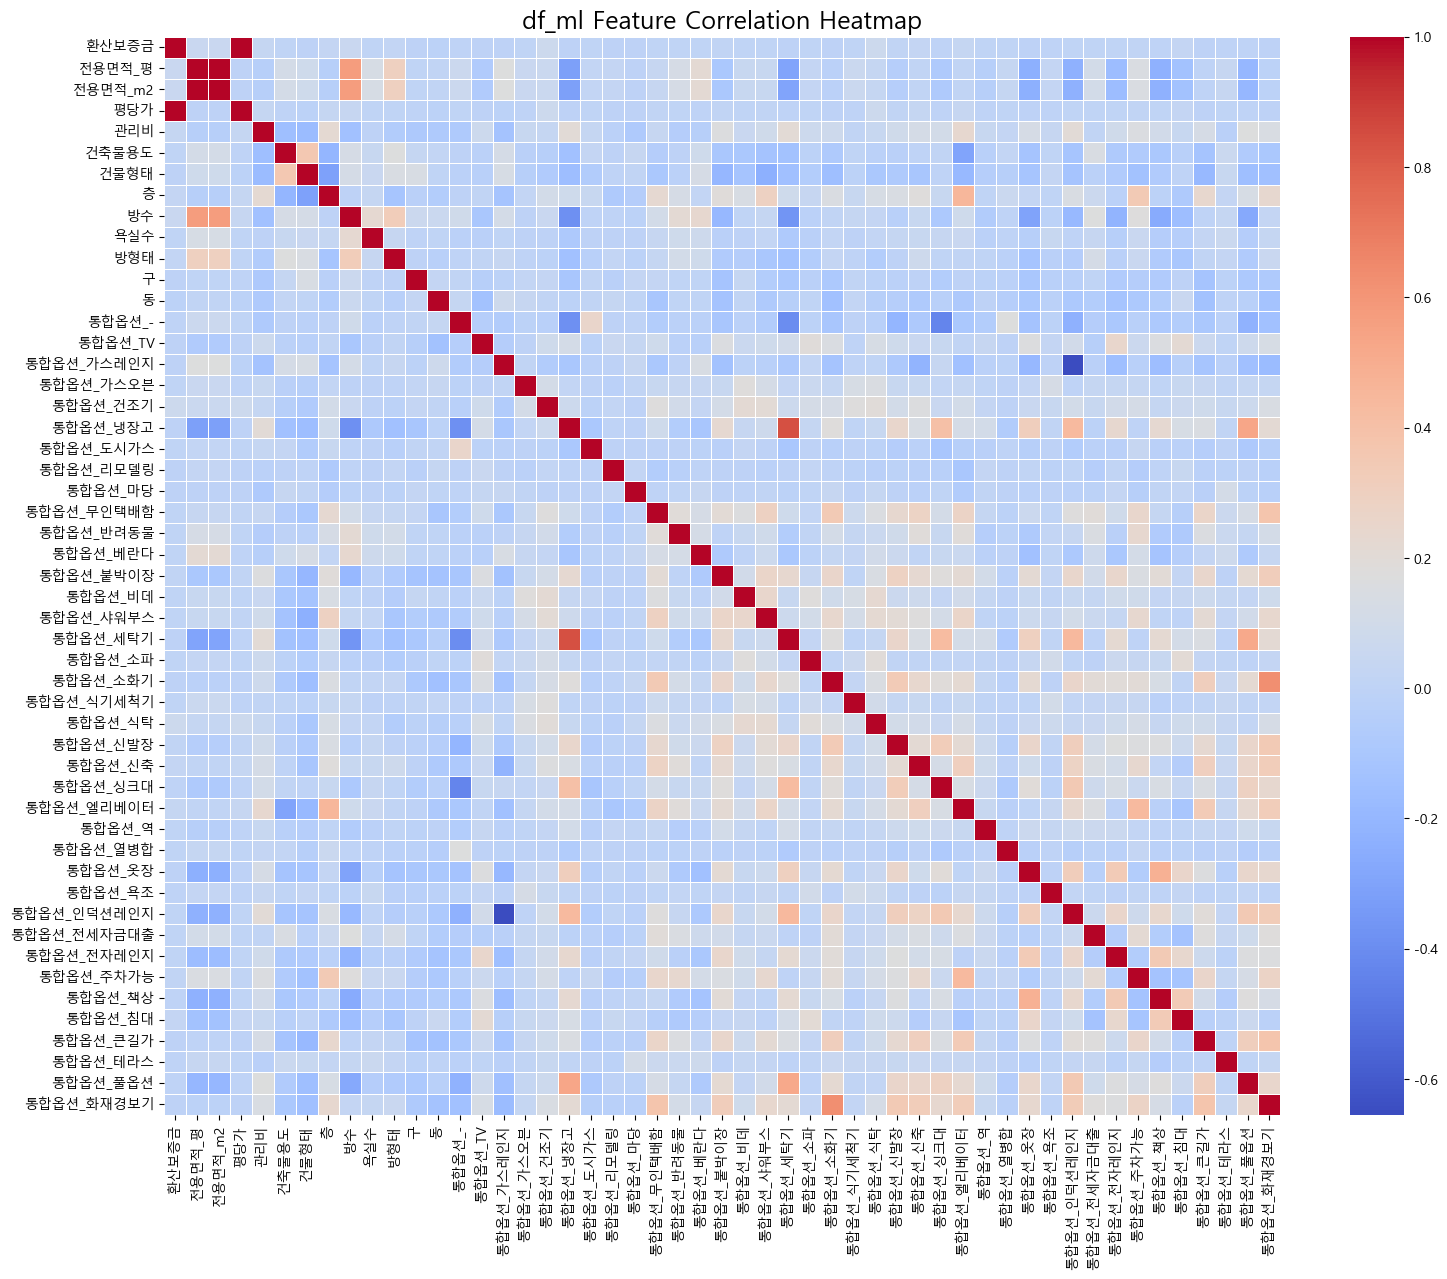

In [58]:

plt.figure(figsize=(18, 14))

corr = df_ml.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=False,           # 숫자 표시하려면 True
    cmap="coolwarm",
    linewidths=0.5,
    square=False
)

plt.title("df_ml Feature Correlation Heatmap", fontsize=18)
plt.show()

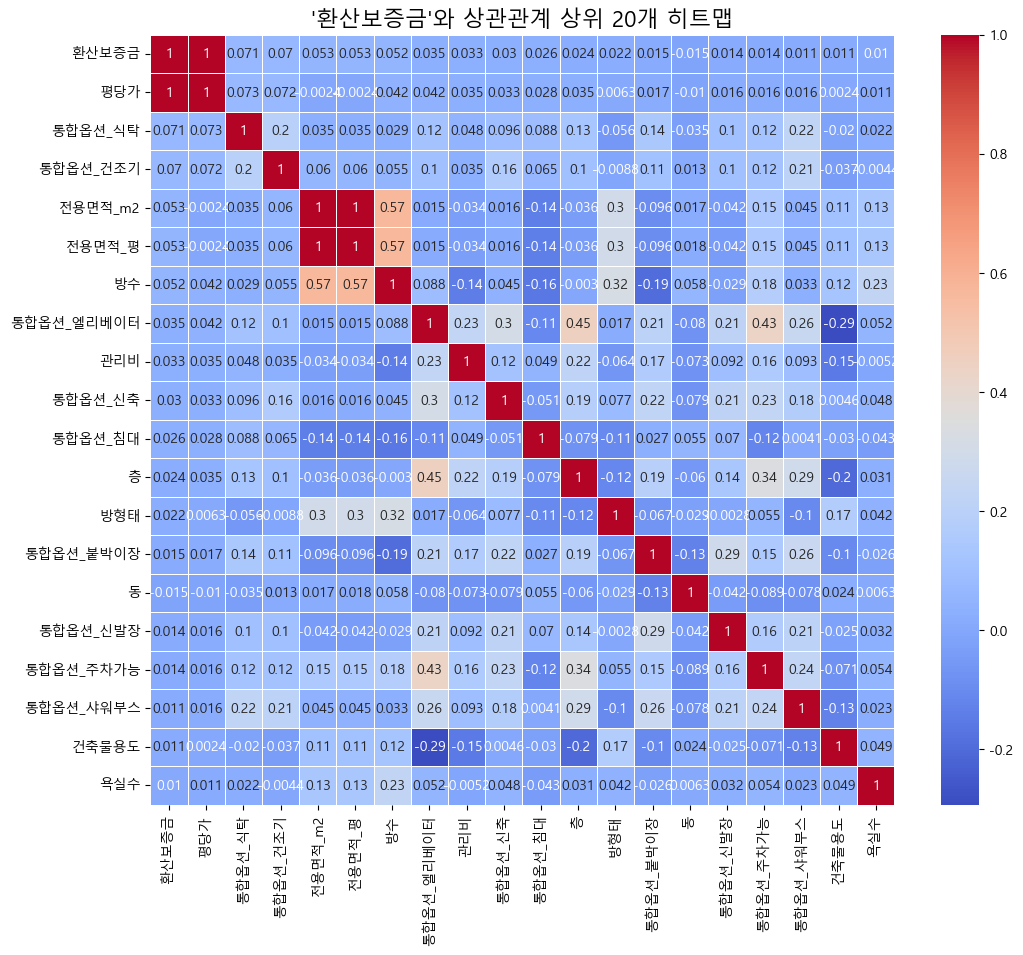

In [59]:
# 1) 숫자 컬럼만 상관관계 계산
corr = df_ml.corr(numeric_only=True)

# 2) 타겟 컬럼 지정
target = "환산보증금"   # ← 너의 타깃 이름으로 변경

# 3) 타겟과 상관관계 높은 상위 20개 선택
top20_cols = corr[target].abs().sort_values(ascending=False).head(20).index.tolist()

# 4) Top20 컬럼들만 슬라이싱해서 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr.loc[top20_cols, top20_cols],
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title(f"'{target}'와 상관관계 상위 20개 히트맵", fontsize=16)
plt.show()

In [60]:
target = "환산보증금"

feature_list = [
    "전용면적_평",
    "전용면적_m2",
    "평당가",
    "관리비",
    "건축물용도",
    "건물형태",
    "층",
    "방수",
    "욕실수",
    "방형태",
    "구",
    "동"
]


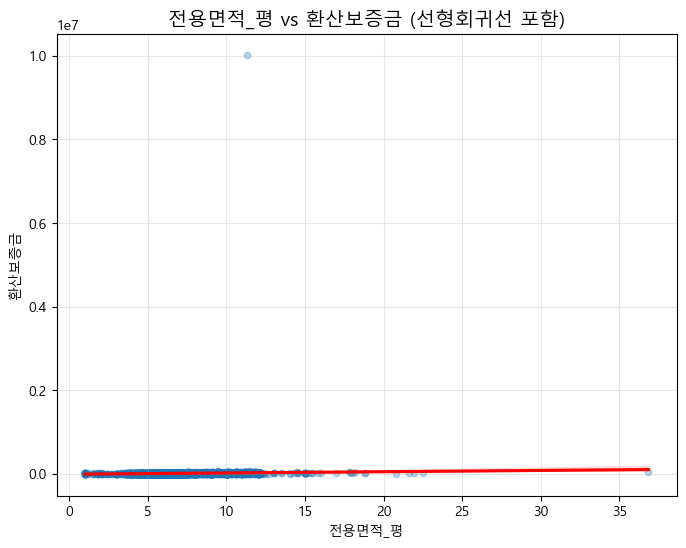

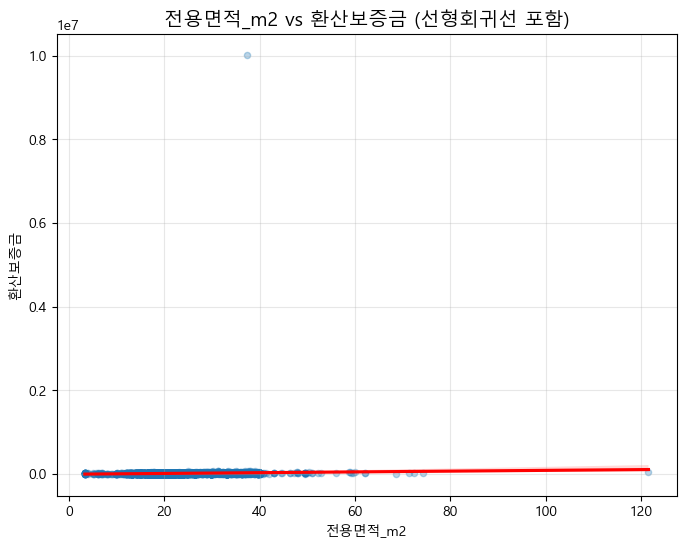

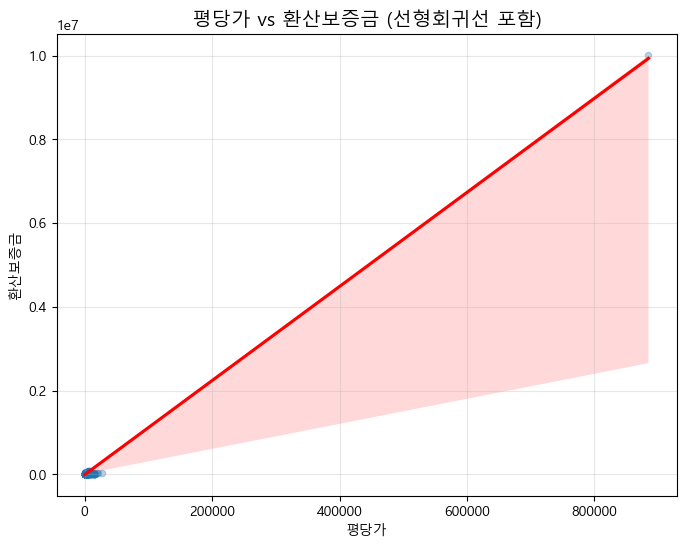

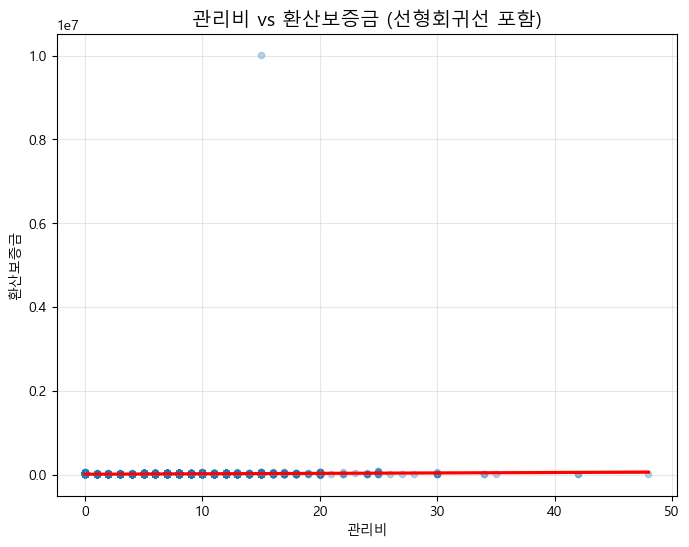

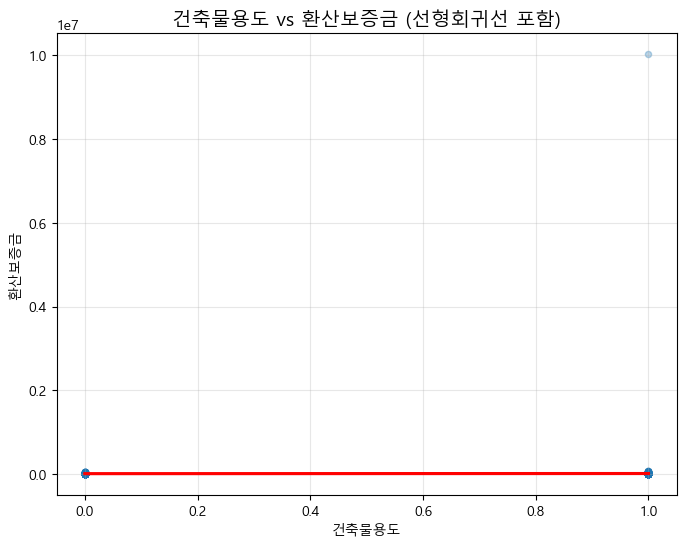

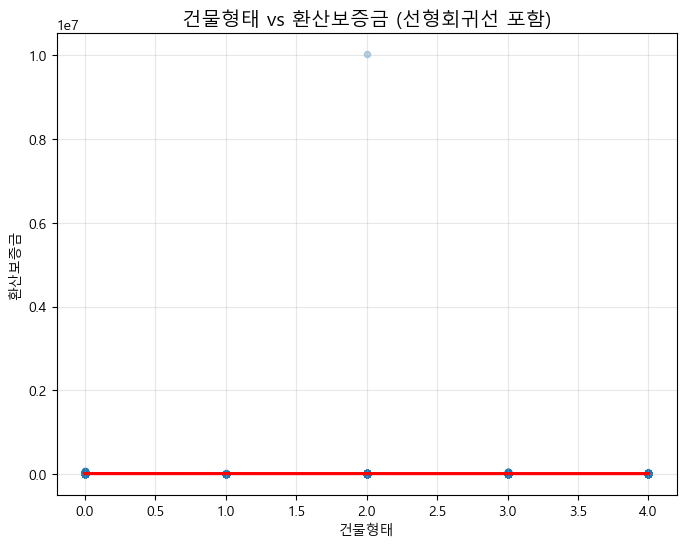

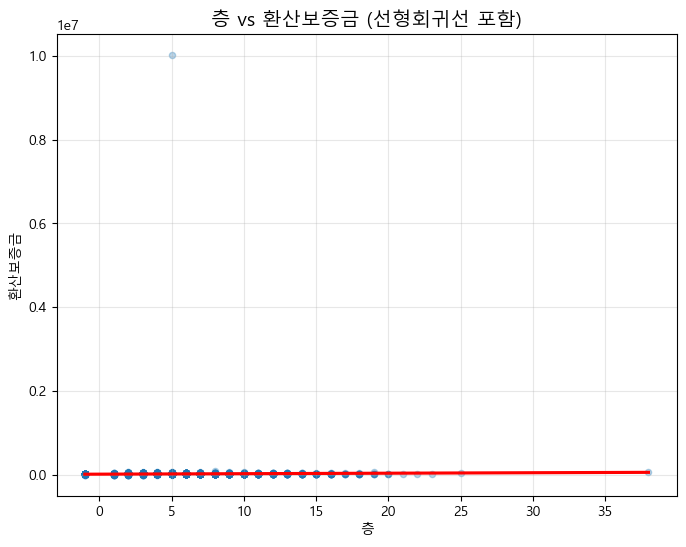

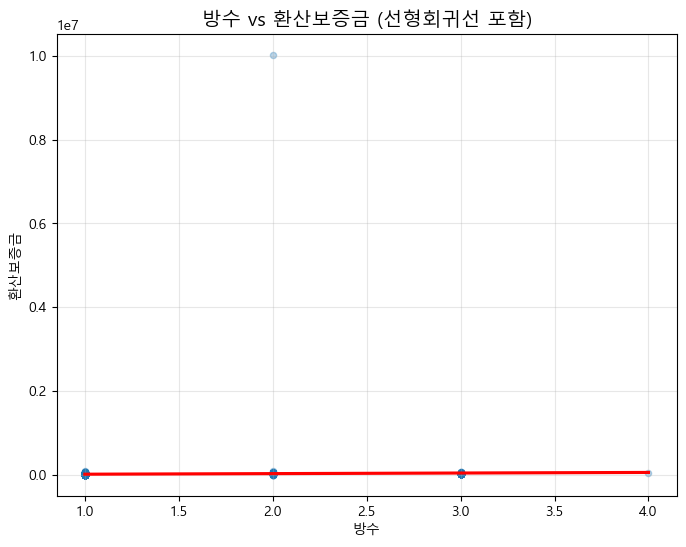

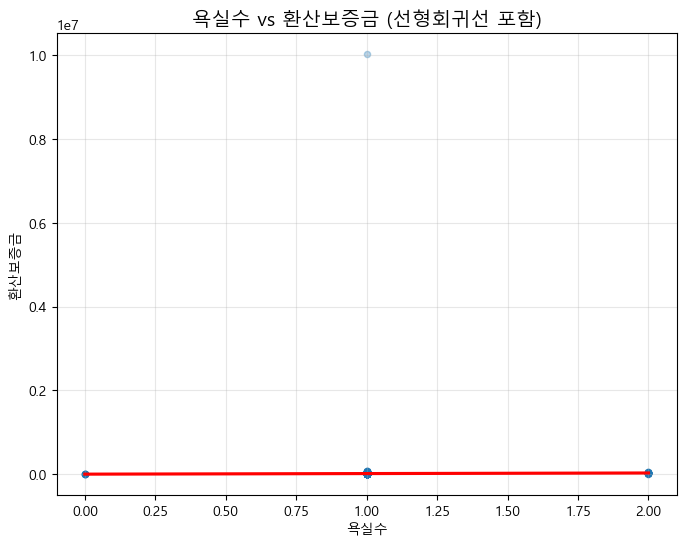

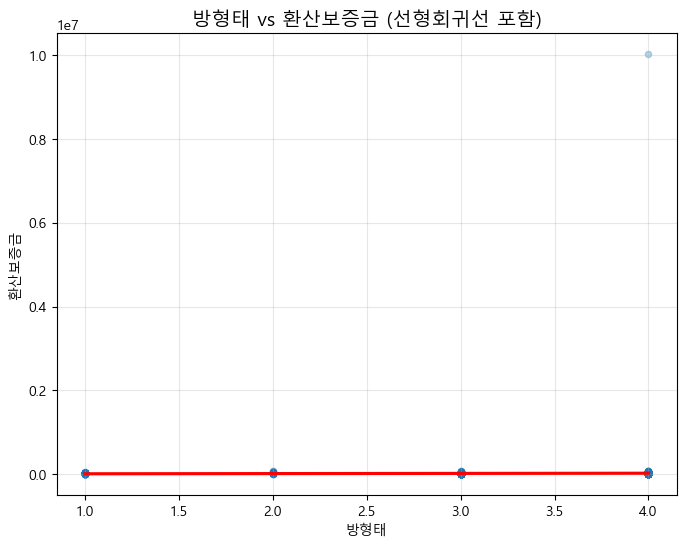

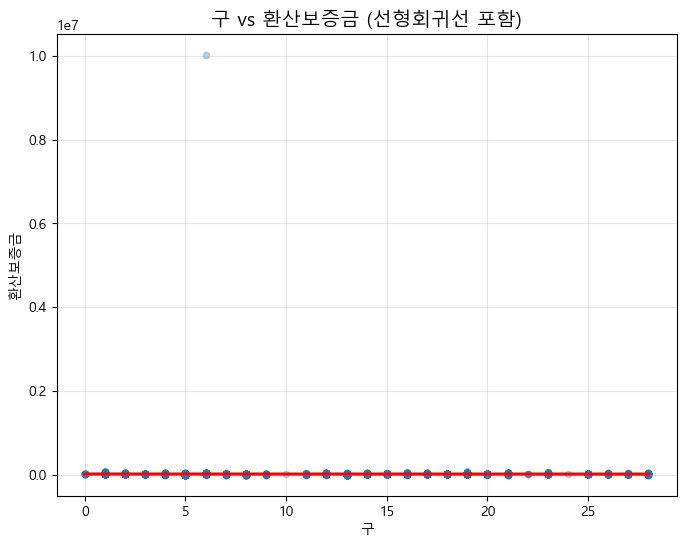

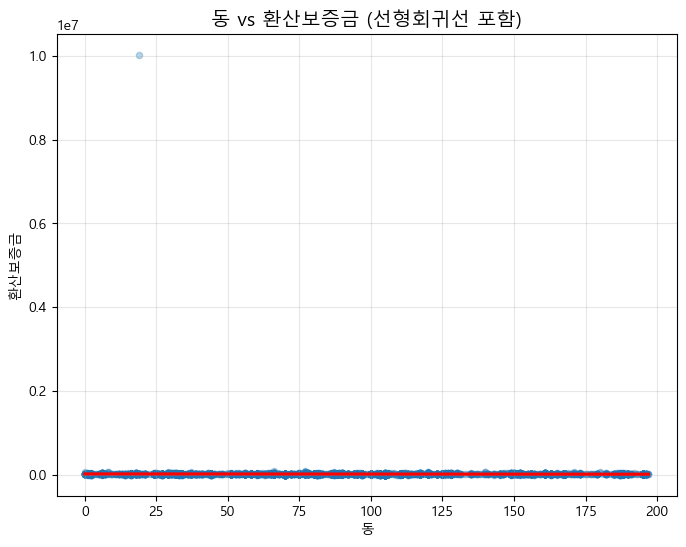

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

for col in feature_list:
    plt.figure(figsize=(8, 6))
    sns.regplot(
        x=df_ml[col],
        y=df_ml[target],
        scatter_kws={"alpha": 0.3, "s": 20},
        line_kws={"color": "red"}
    )
    plt.title(f"{col} vs {target} (선형회귀선 포함)", fontsize=14)
    plt.xlabel(col)
    plt.ylabel(target)
    plt.grid(True, alpha=0.3)
    plt.show()


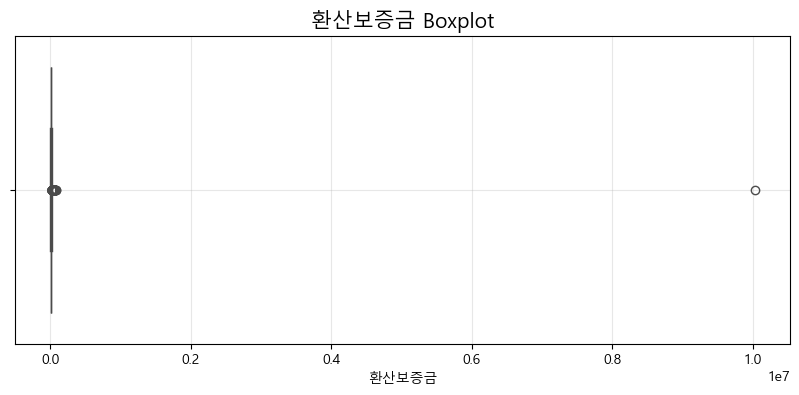

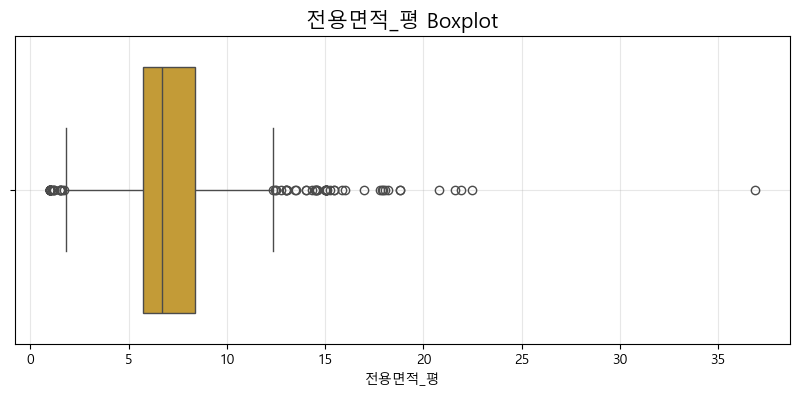

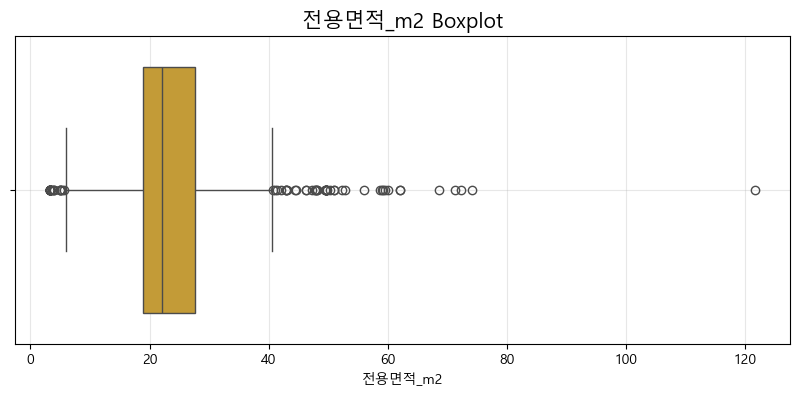

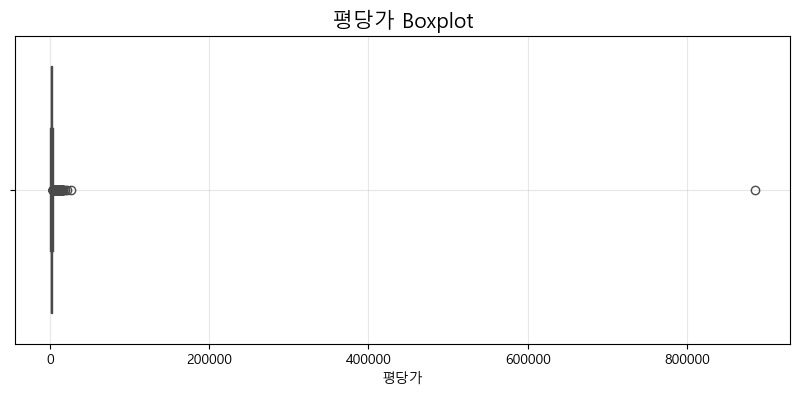

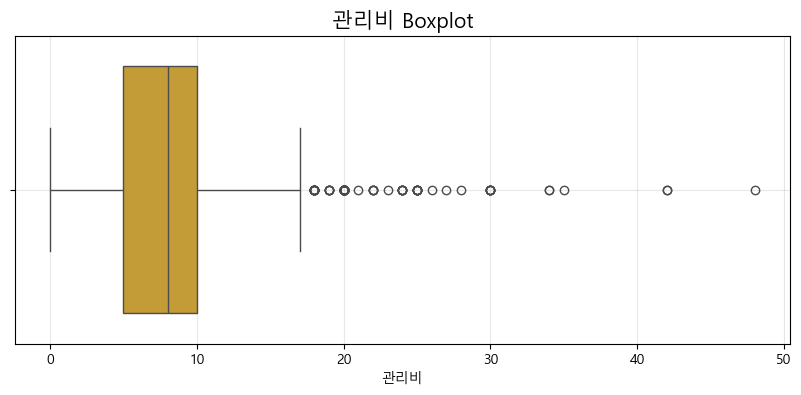

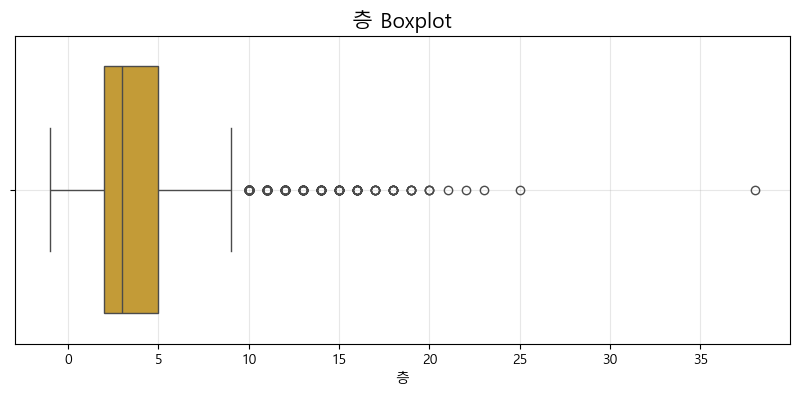

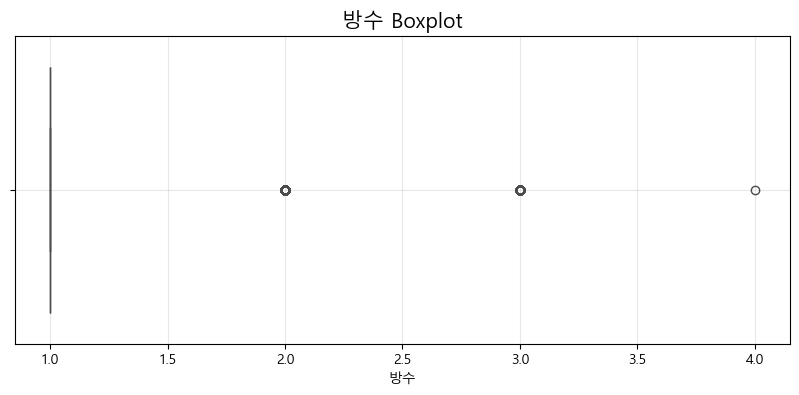

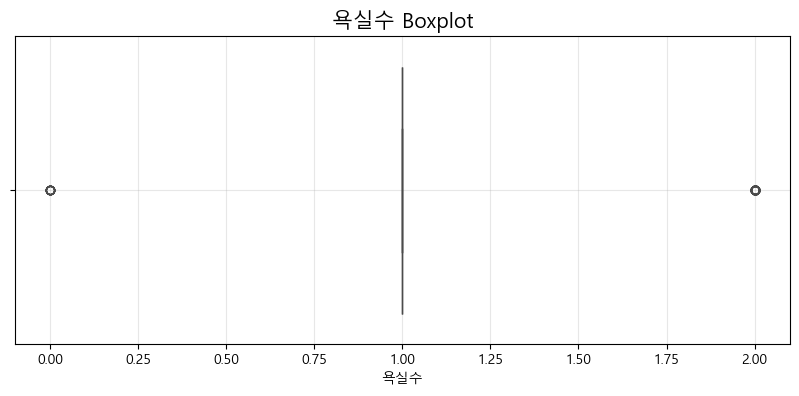

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

num_cols = [
    "환산보증금",
    "전용면적_평",
    "전용면적_m2",
    "평당가",
    "관리비",
    "층",
    "방수",
    "욕실수"
]

for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df_ml[col], color='goldenrod')
    plt.title(f"{col} Boxplot", fontsize=15)
    plt.xlabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()


In [63]:
df_ml["욕실수"].sort_values(ascending=False).head(10)


1179    2
521     2
391     2
2692    2
3620    2
3344    2
901     2
1697    2
571     2
2920    2
Name: 욕실수, dtype: int64

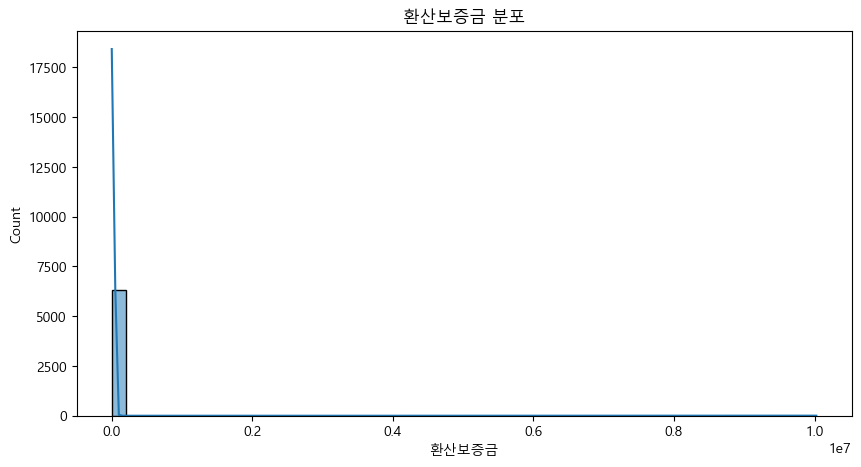

In [65]:
plt.figure(figsize=(10,5))
sns.histplot(df_ml["환산보증금"], bins=50, kde=True)
plt.title("환산보증금 분포")
plt.show()


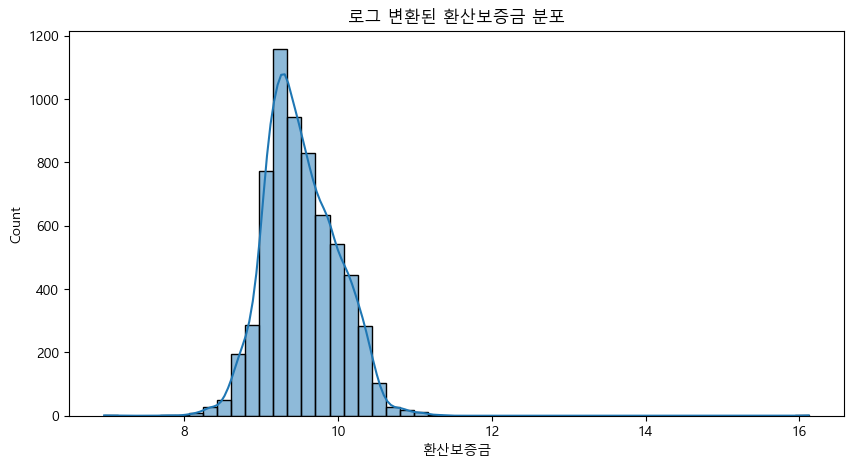

In [66]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(df_ml["환산보증금"]), bins=50, kde=True)
plt.title("로그 변환된 환산보증금 분포")
plt.show()


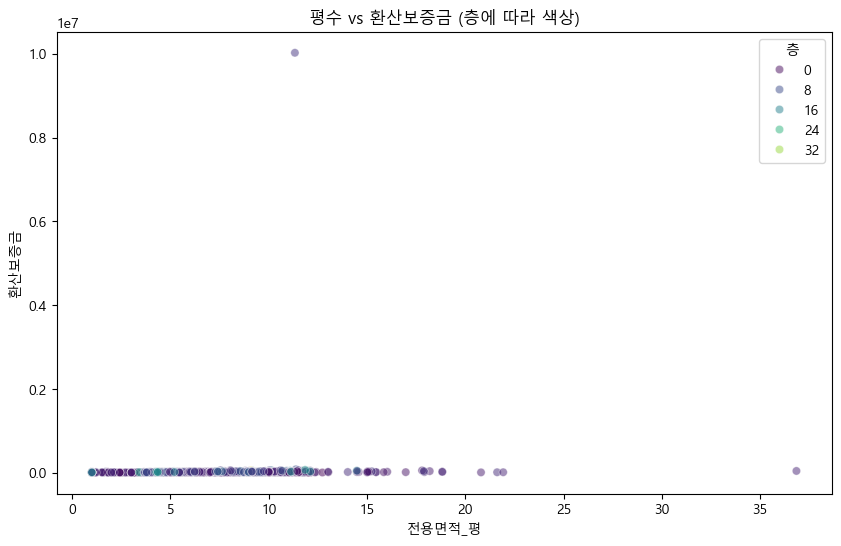

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_ml, 
    x="전용면적_평", 
    y="환산보증금",
    hue="층",
    palette="viridis",
    alpha=0.5
)
plt.title("평수 vs 환산보증금 (층에 따라 색상)")
plt.show()


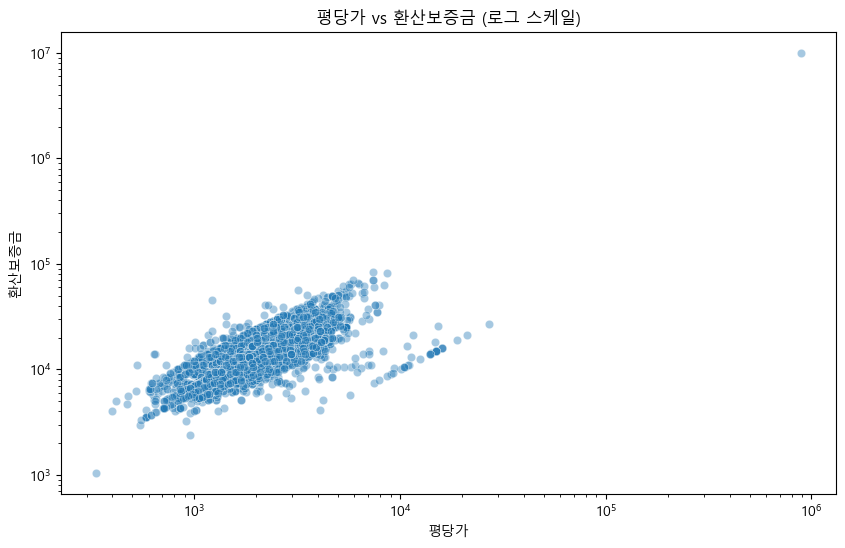

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_ml, x="평당가", y="환산보증금", alpha=0.4)
plt.xscale("log")
plt.yscale("log")
plt.title("평당가 vs 환산보증금 (로그 스케일)")
plt.show()


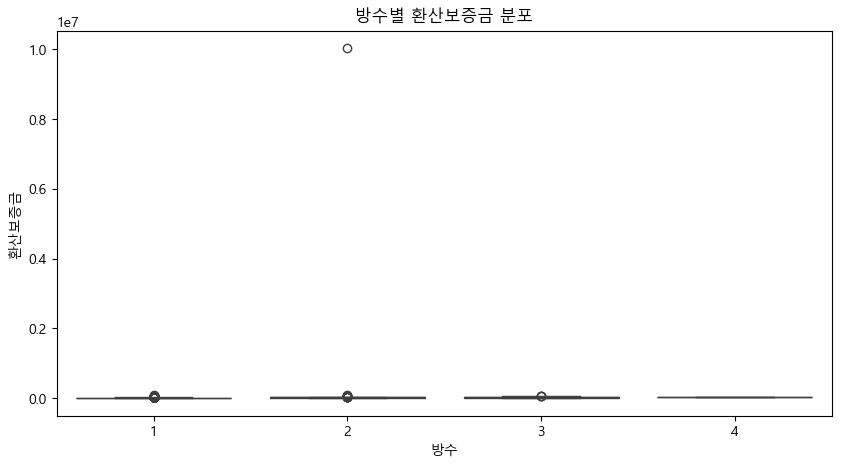

In [69]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_ml, x="방수", y="환산보증금")
plt.title("방수별 환산보증금 분포")
plt.show()


In [ ]:
target = "환산보증금"   # <- 타겟 이름

X = df_ml.drop(columns=[target])
y = df_ml[target]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)


In [ ]:
# 예측(로그 스케일에서 학습했으므로 역변환)
# 안정화된 흐름:
# 1) 모델이 이미 학습되었는지 검사
# 2) 학습되지 않았다면 내부 검증셋(X_tr/X_val)이 있으면 조기종료 포함 학습,
#    없으면 전체 훈련데이터(X_train)로 학습
# 3) 예측은 가능한 한 early-stopping에서 얻은 best_iteration(있을 때)을 사용

import warnings
import numpy as np
from sklearn.utils.validation import check_is_fitted

def is_fitted_model(m):
    try:
        check_is_fitted(m)
        return True
    except Exception:
        return False

# 1) 학습 여부 확인
if not is_fitted_model(model):
    warnings.warn("모델이 학습되지 않았습니다. 적절한 데이터가 있으면 학습을 수행합니다.")
    # 우선 내부 검증셋이 있을 경우 조기종료 포함 학습
    if all(v in globals() for v in ('X_tr', 'y_tr', 'X_val', 'y_val')):
        try:
            model.fit(
                X_tr,
                y_tr,
                eval_set=[(X_val, y_val)],
                eval_metric='rmse',
                early_stopping_rounds=50,
                verbose=50,
            )
        except Exception as e:
            warnings.warn(f"내부 검증으로 학습 시도 중 오류 발생: {e}. 전체 학습 데이터로 재시도합니다.")
            if 'X_train' in globals() and 'y_train_log' in globals():
                model.fit(X_train, y_train_log)
            else:
                raise RuntimeError("학습할 데이터가 없습니다 (X_tr/X_train).")
    # 내부 검증셋이 없을 경우 전체 학습 데이터로 학습
    elif 'X_train' in globals() and 'y_train_log' in globals():
        model.fit(X_train, y_train_log)
    else:
        raise RuntimeError("모델을 학습할 데이터(X_tr 또는 X_train)가 존재하지 않습니다.")

# 2) 예측 (가능하면 best_iteration 사용)
try:
    # XGBoost scikit-learn wrapper에서는 booster의 best_iteration을 활용할 수 있음
    y_pred_log = None
    if hasattr(model, 'get_booster'):
        try:
            booster = model.get_booster()
            best_it = getattr(booster, 'best_iteration', None)
            if best_it is not None and best_it > 0:
                # sklearn wrapper predict에 iteration_range 지원 (XGBoost 버전에 따라 동작)
                try:
                    y_pred_log = model.predict(X_test, iteration_range=(0, best_it+1))
                except Exception:
                    # fallback
                    y_pred_log = model.predict(X_test)
            else:
                y_pred_log = model.predict(X_test)
        except Exception:
            y_pred_log = model.predict(X_test)
    else:
        y_pred_log = model.predict(X_test)
except Exception as e:
    # 예측 자체가 실패하면 상세 에러와 함께 중단
    raise RuntimeError(f"모델 예측 실패: {e}")

# 역변환
y_pred = np.expm1(y_pred_log)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_26612\1267701152.py:21: UserWarning: 모델이 학습되지 않았습니다. 적절한 데이터가 있으면 학습을 수행합니다.
  warnings.warn("모델이 학습되지 않았습니다. 적절한 데이터가 있으면 학습을 수행합니다.")
C:\Users\Playdata\AppData\Local\Temp\ipykernel_26612\1267701152.py:34: UserWarning: 내부 검증으로 학습 시도 중 오류 발생: XGBModel.fit() got an unexpected keyword argument 'eval_metric'. 전체 학습 데이터로 재시도합니다.
  warnings.warn(f"내부 검증으로 학습 시도 중 오류 발생: {e}. 전체 학습 데이터로 재시도합니다.")


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 테스트 타깃 역변환 (로그 역변환)
y_test_orig = np.expm1(y_test_log)

mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)

print("=== XGBoost 모델 성능 ===")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R^2  : {r2:.4f}")


=== XGBoost 모델 성능 ===
MAE  : 2,300.80
RMSE : 3,505.60
R^2  : 0.7854


In [ ]:
df_compare = pd.DataFrame({
    "실제값": y_test_orig.values[:10],
    "예측값": y_pred[:10]
})
df_compare


,실제값,예측값
0,11000.0,11433.037109
1,29000.0,28299.591797
2,20000.0,17835.316406
3,12000.0,13319.784180
4,8300.0,9526.791992
5,9700.0,7893.697266
6,10300.0,10368.697266
7,12000.0,11164.621094
8,18900.0,18558.644531
9,15000.0,10200.425781


In [ ]:
import numpy as np

mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100

print(f"전체 평균 오차율(MAPE): {mape:.2f}%")


전체 평균 오차율(MAPE): 16.26%


In [ ]:
import numpy as np

# 오차율 계산
df_compare = pd.DataFrame({
    "실제값": y_test_orig.values,
    "예측값": y_pred
})

df_compare["오차율(%)"] = np.abs((df_compare["실제값"] - df_compare["예측값"]) / df_compare["실제값"]) * 100


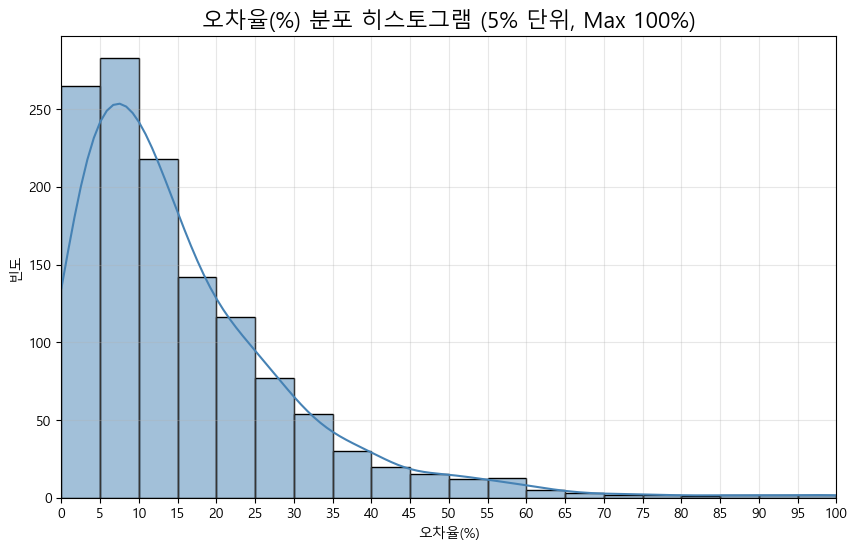

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 1) 오차율 5% 단위 bin 생성
bins = np.arange(0, 105, 5)

# 2) 히스토그램
plt.figure(figsize=(10, 6))
sns.histplot(
    df_compare["오차율(%)"],
    bins=bins,
    kde=True,
    color='steelblue',
    edgecolor='black'
)

# 3) X축 0~100%로 제한
plt.xlim(0, 100)
plt.xticks(bins)  # 5% 간격 표시

plt.title("오차율(%) 분포 히스토그램 (5% 단위, Max 100%)", fontsize=16)
plt.xlabel("오차율(%)")
plt.ylabel("빈도")
plt.grid(True, alpha=0.3)
plt.show()


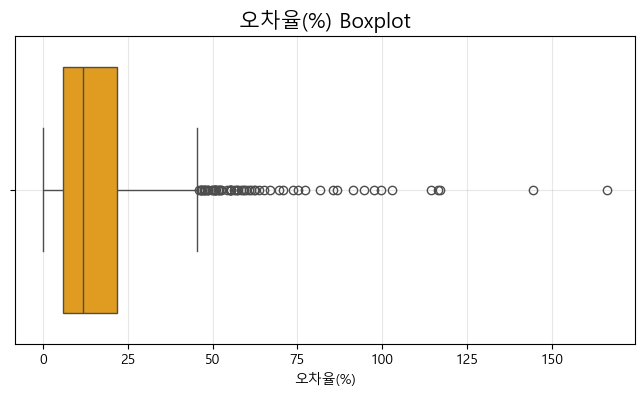

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_compare["오차율(%)"], color='orange')

plt.title("오차율(%) Boxplot", fontsize=15)
plt.xlabel("오차율(%)")
plt.grid(True, alpha=0.3)
plt.show()


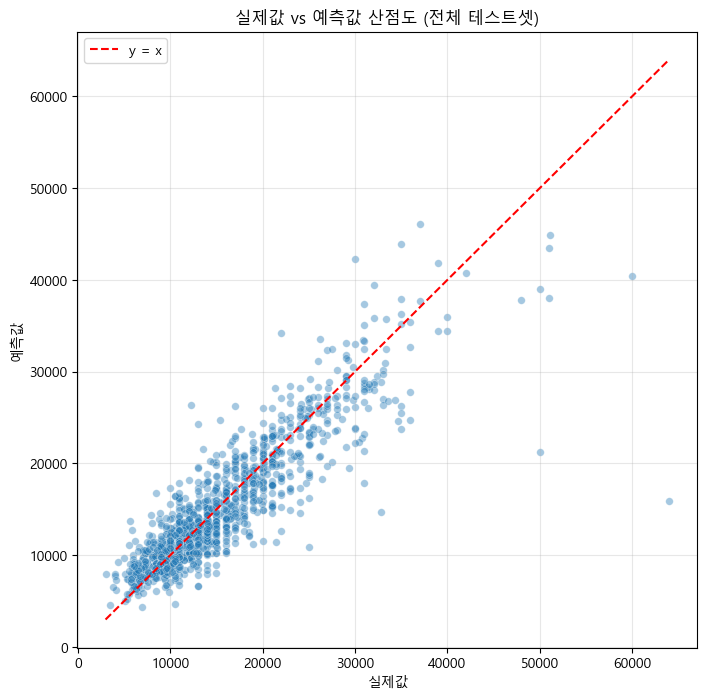

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, s=30)

max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.xlabel("실제값")
plt.ylabel("예측값")
plt.title("실제값 vs 예측값 산점도 (전체 테스트셋)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
import shap

shap.initjs()

# 전체 데이터 사용
X_test_sample = X_test.copy()   # 샘플링 제거


In [ ]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)


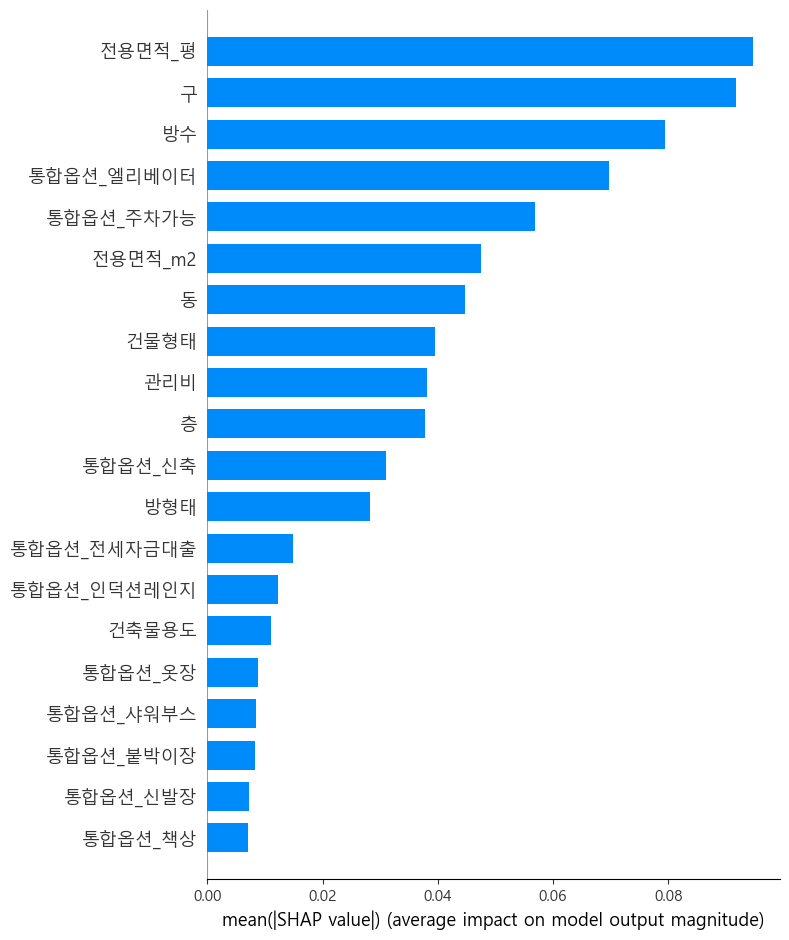

In [ ]:
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=20)


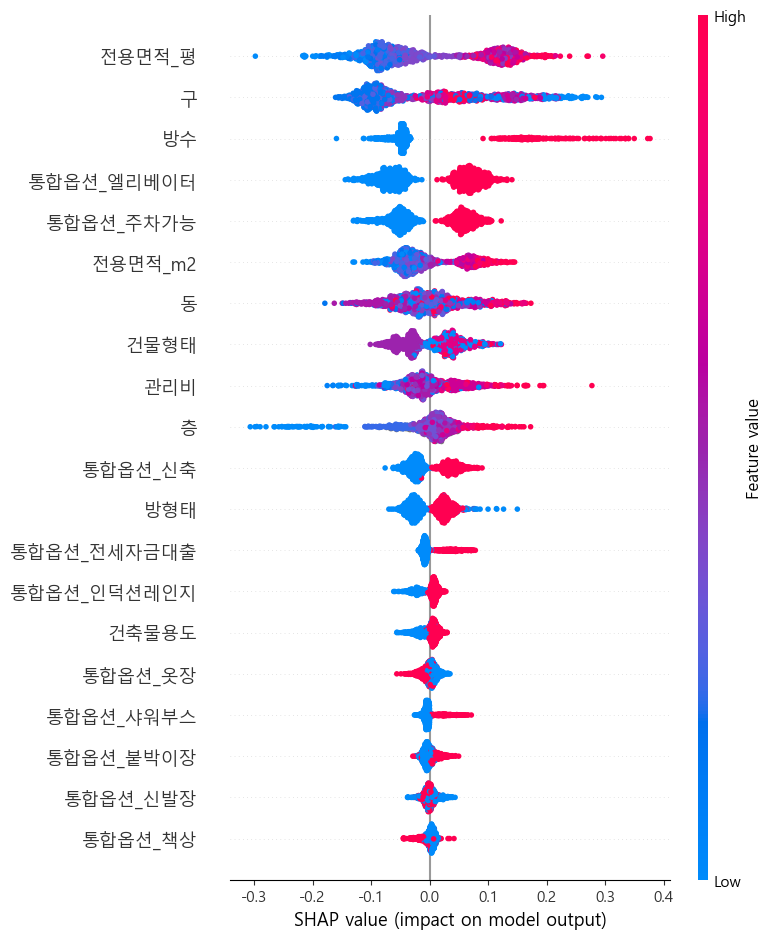

In [ ]:
shap.summary_plot(shap_values, X_test_sample, max_display=20)


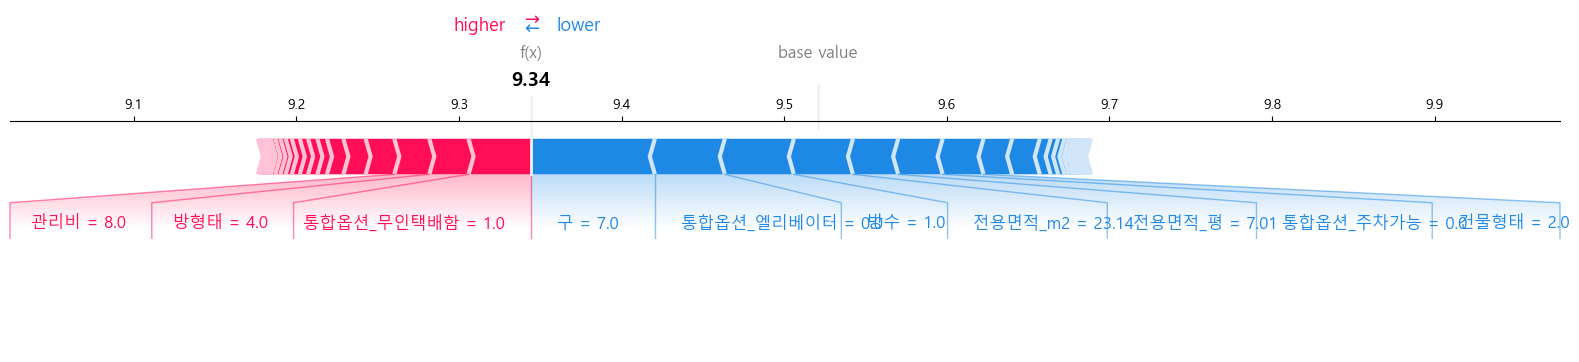

In [ ]:
idx = X_test_sample.index[0]   # 샘플 하나 선택
shap.force_plot(
    explainer.expected_value,
    shap_values[X_test_sample.index.get_loc(idx)],
    X_test_sample.loc[idx],
    matplotlib=True
)
